In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

In [36]:
#ticker = 'NVDA'
#ticker = 'GOOG'
ticker = 'AMZN'
#ticker = 'META'

In [37]:
# Import the stock data
data = yf.download(ticker, start='2023-01-01', end='2026-04-07')
print("Number of rows of data imported: {}".format(data.shape[0]))
#data['Returns'] = data['Close'].pct_change() # Calculate % change for each day
data['Returns'] = np.log(data['Close'] / data['Close'].shift(1))

C:\Users\neilj\AppData\Local\Temp\ipykernel_2348\2036080045.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2023-01-01', end='2026-04-07')
[*********************100%***********************]  1 of 1 completed

Number of rows of data imported: 816


In [38]:
# Check how it looks
data.head()

Price,Close,High,Low,Open,Volume,Returns
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN,
Date,,,,,,
2023-01-03,85.820000,86.959999,84.209999,85.459999,76706000,NaN
2023-01-04,85.139999,86.980003,83.360001,86.550003,68885100,-0.007955
2023-01-05,83.120003,85.419998,83.070000,85.330002,67930800,-0.024012
2023-01-06,86.080002,86.400002,81.430000,83.029999,83303400,0.034992
2023-01-09,87.360001,89.480003,87.080002,87.459999,65266100,0.014760


In [39]:
# Set some parameters for your simulation
num_simulations = 10000
num_days = 25
last_price = data['Close'].iloc[-1,0]
simulation_df = np.zeros((num_days, num_simulations))
mu = data['Returns'].mean()
sigma = data['Returns'].std()

In [40]:
# Run the Monte Carlo simulation
shocks = np.random.normal(size=(num_days, num_simulations))
drift = (mu - 0.5 * sigma**2)
diffusion = sigma * shocks

# Calculate all returns at once
daily_growth = np.exp(drift + diffusion)

# Stack them and calculate cumulative product to get prices
simulation_df = last_price * daily_growth.cumprod(axis=0)

final_prices = simulation_df[-1:]
median_final_price = np.median(final_prices)
most_likely_simulation_index = np.argmin(np.abs(final_prices - median_final_price))
most_likely_simulation = simulation_df[:, most_likely_simulation_index]

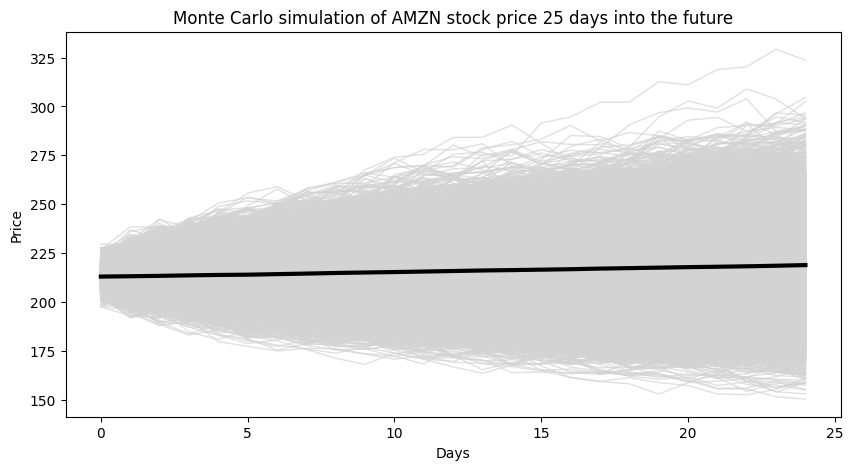

The most likely (median) stock price for AMZN in 25 days time is 218.05461504378468


In [41]:
# Plot the Monte Carlo output
# Results of each individual simulation are shown in grey, the thick black line is the mean
plt.figure(figsize=(10,5))
plt.plot(simulation_df, color='lightgray', alpha=0.7, linewidth=1)
mean_path = simulation_df.mean(axis=1)
plt.plot(mean_path, color='black', linewidth=3, label='Mean Path')
plt.title('Monte Carlo simulation of {} stock price {} days into the future'.format(ticker, num_days)) 
plt.xlabel('Days')
plt.ylabel('Price')
plt.show()
print("The most likely (median) stock price for {} in {} days time is {}".format(ticker, num_days, most_likely_simulation[-1]))